Dataset Shape: (200, 5)

First 5 rows:
   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9

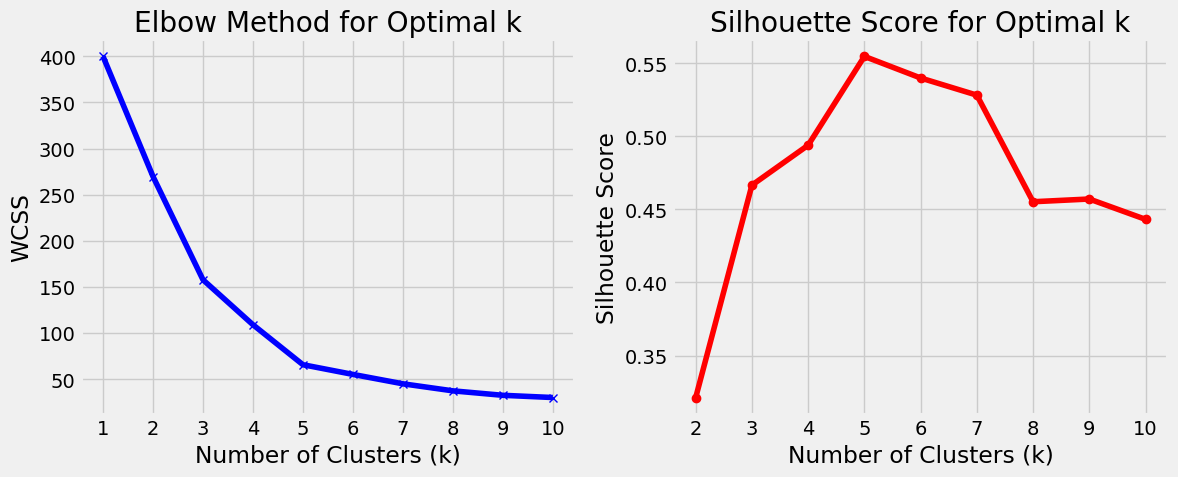

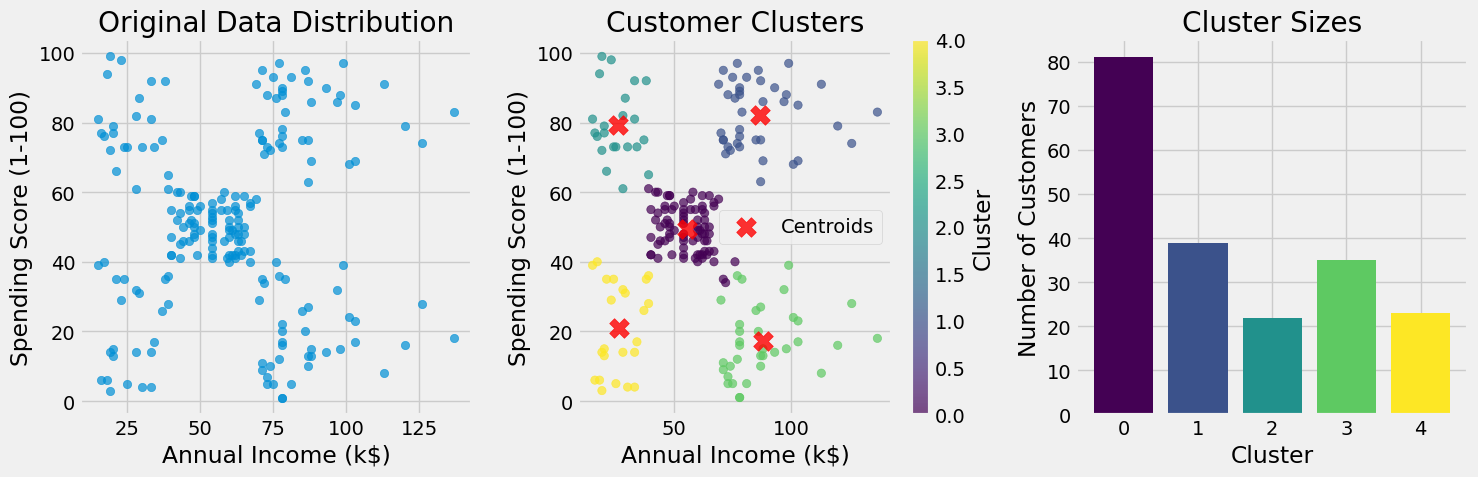

Cluster Analysis:
         Income_Mean  Income_Std  Income_Min  Income_Max  Spending_Mean  \
Cluster                                                                   
0              55.30        8.99          39          76          49.52   
1              86.54       16.31          69         137          82.13   
2              25.73        7.57          15          39          79.36   
3              88.20       16.40          70         137          17.11   
4              26.30        7.89          15          39          20.91   

         Spending_Std  Spending_Min  Spending_Max  Customer_Count  
Cluster                                                            
0                6.53            34            61              81  
1                9.36            63            97              39  
2               10.50            61            99              22  
3                9.95             1            39              35  
4               13.02             3            4

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
import warnings
warnings.filterwarnings('ignore')

# Set style for better visualization
plt.style.use('fivethirtyeight')

# Load the dataset (assuming it's named 'Mall_Customers.csv')
# If you have a different file name, replace it accordingly
df = pd.read_csv('Mall_Customers.csv')

# Display basic information
print("Dataset Shape:", df.shape)
print("\nFirst 5 rows:")
print(df.head())

print("\nDataset Information:")
print(df.info())

print("\nStatistical Summary:")
print(df.describe())

print("\nMissing Values:")
print(df.isnull().sum())


# Select relevant features for clustering
# Typically, we use Annual Income and Spending Score for mall customer segmentation
X = df[['Annual Income (k$)', 'Spending Score (1-100)']]

# Standardize the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Convert back to DataFrame for better visualization
X_df = pd.DataFrame(X_scaled, columns=['Annual Income', 'Spending Score'])



# Method 1: Elbow Method
wcss = []  # Within-Cluster Sum of Square
cluster_range = range(1, 11)

for k in cluster_range:
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

# Plot Elbow Method
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(cluster_range, wcss, 'bx-')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('WCSS')
plt.title('Elbow Method for Optimal k')
plt.xticks(cluster_range)

# Method 2: Silhouette Score
silhouette_scores = []
for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    score = silhouette_score(X_scaled, kmeans.labels_)
    silhouette_scores.append(score)

plt.subplot(1, 2, 2)
plt.plot(range(2, 11), silhouette_scores, 'ro-')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score for Optimal k')
plt.xticks(range(2, 11))

plt.tight_layout()
plt.show()


# Based on the elbow method and silhouette score, choose optimal k
optimal_k = 5  # This is typical for mall customer dataset

# Apply K-Means with optimal k
kmeans = KMeans(n_clusters=optimal_k, init='k-means++', random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_scaled)

# Add cluster labels to original dataframe
df['Cluster'] = clusters
X_df['Cluster'] = clusters



plt.figure(figsize=(15, 5))

# Original data
plt.subplot(1, 3, 1)
plt.scatter(X['Annual Income (k$)'], X['Spending Score (1-100)'], alpha=0.7)
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.title('Original Data Distribution')

# Clustered data
plt.subplot(1, 3, 2)
scatter = plt.scatter(X['Annual Income (k$)'], X['Spending Score (1-100)'],
                     c=clusters, cmap='viridis', alpha=0.7)
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.title('Customer Clusters')
plt.colorbar(scatter, label='Cluster')

# Cluster centers in original scale
centers_original = scaler.inverse_transform(kmeans.cluster_centers_)
plt.scatter(centers_original[:, 0], centers_original[:, 1],
           c='red', marker='X', s=200, alpha=0.8, label='Centroids')
plt.legend()

# Cluster sizes
plt.subplot(1, 3, 3)
cluster_counts = df['Cluster'].value_counts().sort_index()
plt.bar(cluster_counts.index, cluster_counts.values, color=plt.cm.viridis(np.linspace(0, 1, optimal_k)))
plt.xlabel('Cluster')
plt.ylabel('Number of Customers')
plt.title('Cluster Sizes')
plt.xticks(cluster_counts.index)

plt.tight_layout()
plt.show()



# Analyze cluster characteristics
cluster_analysis = df.groupby('Cluster').agg({
    'Annual Income (k$)': ['mean', 'std', 'min', 'max'],
    'Spending Score (1-100)': ['mean', 'std', 'min', 'max'],
    'CustomerID': 'count'  # Number of customers in each cluster
}).round(2)

cluster_analysis.columns = ['Income_Mean', 'Income_Std', 'Income_Min', 'Income_Max',
                           'Spending_Mean', 'Spending_Std', 'Spending_Min', 'Spending_Max',
                           'Customer_Count']

print("Cluster Analysis:")
print(cluster_analysis)

# Interpret clusters
print("\nCluster Interpretation:")
cluster_interpretation = {
    0: "High Income, Low Spending - Careful Customers",
    1: "Medium Income, Medium Spending - Standard Customers",
    2: "High Income, High Spending - Target Customers",
    3: "Low Income, High Spending - Careless Customers",
    4: "Low Income, Low Spending - Sensible Customers"
}

for cluster_num in range(optimal_k):
    print(f"Cluster {cluster_num}: {cluster_interpretation.get(cluster_num, 'Unknown')}")


# If you have gender information, you can analyze gender distribution per cluster
if 'Gender' in df.columns:
    gender_cluster = pd.crosstab(df['Cluster'], df['Gender'], normalize='index') * 100
    print("\nGender Distribution per Cluster (%):")
    print(gender_cluster.round(2))

# If you have age information
if 'Age' in df.columns:
    age_cluster = df.groupby('Cluster')['Age'].agg(['mean', 'std']).round(2)
    print("\nAge Statistics per Cluster:")
    print(age_cluster)



# Save the clustered data
df.to_csv('mall_customers_clustered.csv', index=False)

# Save cluster centers
cluster_centers_df = pd.DataFrame(centers_original,
                                 columns=['Annual Income (k$)', 'Spending Score (1-100)'])
cluster_centers_df['Cluster'] = range(optimal_k)
cluster_centers_df.to_csv('cluster_centers.csv', index=False)

print("Results saved successfully!")



def main():
    # Load and preprocess data
    df = pd.read_csv('Mall_Customers.csv')
    X = df[['Annual Income (k$)', 'Spending Score (1-100)']]

    # Scale data
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    # Apply K-means
    kmeans = KMeans(n_clusters=5, init='k-means++', random_state=42, n_init=10)
    clusters = kmeans.fit_predict(X_scaled)
    df['Cluster'] = clusters

    # Analyze results
    analyze_clusters(df, kmeans, scaler)

    return df, kmeans

def analyze_clusters(df, kmeans, scaler):
    # Your analysis code here (from steps 6-8)
    pass

if __name__ == "__main__":
    clustered_data, model = main()